<a href="https://colab.research.google.com/github/alishermutalov/deep-learning-projects/blob/deep-learning/deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from fastai.vision.all import *
from ipywidgets import widgets

path = untar_data(URLs.PETS)/'images'

def is_cat(x): return x[0].isupper()

dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), label_func=is_cat, item_tfms=Resize(224))

learn = cnn_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(2)


/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 102MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,0.167345,0.015852,0.994587,00:45


epoch,train_loss,valid_loss,accuracy,time
0,0.057102,0.024476,0.990528,00:52
1,0.031102,0.008415,0.997970,00:47


In [2]:
upload = widgets.FileUpload()
upload

FileUpload(value={}, description='Upload')

Is cat? True
Probability: 1.000


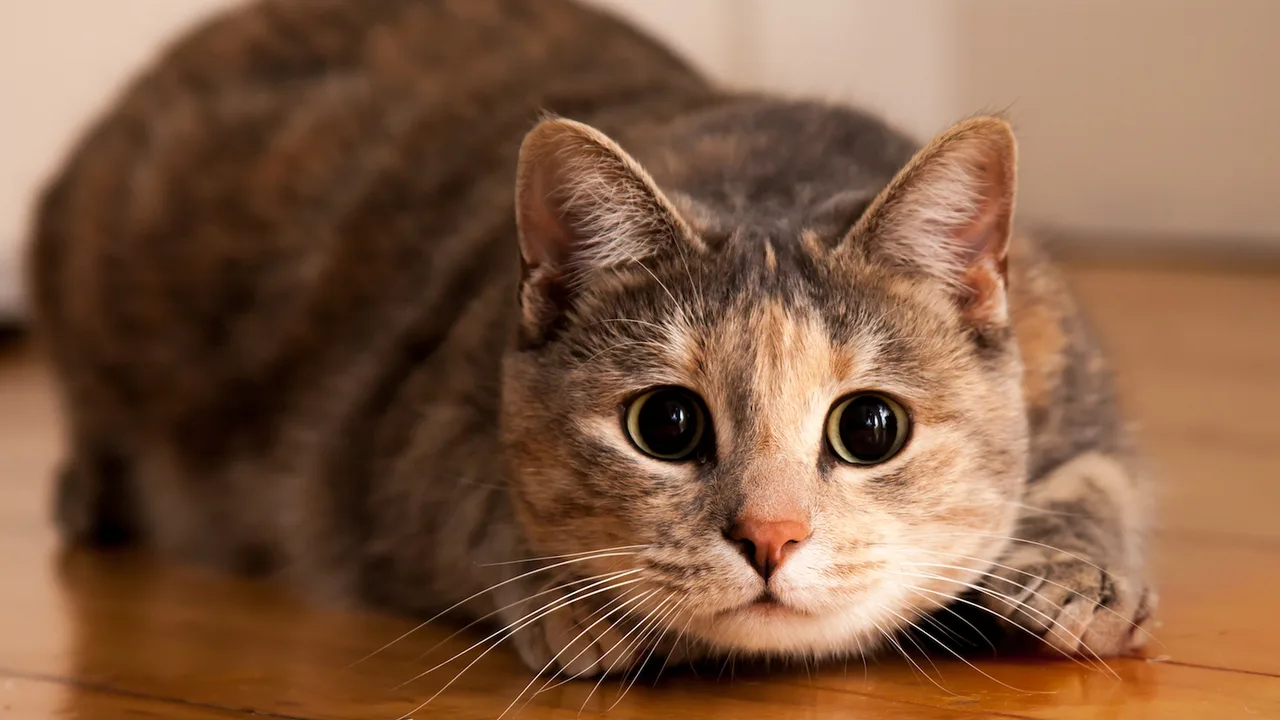

In [6]:
img = PILImage.create(upload.data[-1])
pred, _, prob = learn.predict(img)
print(f"Is cat? {pred}")
print(f"Probability: {prob[1].item():.3f}")
img